In [380]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## Questão 01 

a) Considerando uma validação cruzada em 10 folds, avalie modelos de *classificação binária* nos dados em questão.


b) Para cada modelo criado, reporte valor médio e desvio padrão da acurácia
global e da acurácia por classe.

In [381]:
# extraindo dados
breast = np.genfromtxt("breastcancer.csv", delimiter=',')

In [382]:
np.shape(breast)

(569, 31)

### K-fold

In [383]:
# função que divide o dataset em k-folds

def kfold_ind(k, X, y):
    tam_fold = len(X) // k
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    folds_norm = []
    
    for i in range(k):
        teste_indices = indices[i * tam_fold: (i+1) * tam_fold]
        treino_indices = np.concatenate([indices[:i * tam_fold], indices[(i+1) * tam_fold:]])
        
        X_treino, X_teste = X[treino_indices], X[teste_indices]
        y_treino, y_teste = y[treino_indices], y[teste_indices]
        
        media = np.mean(X_treino, axis=0)
        desvio = np.std(X_treino, axis=0)
        desvio[desvio == 0] = 1
        
        X_treino_norm = (X_treino - media) / desvio
        X_teste_norm = (X_teste - media) / desvio
        
        X_treino_norm = np.concatenate((np.ones((X_treino_norm.shape[0], 1)), X_treino_norm), axis=1)
        X_teste_norm = np.concatenate((np.ones((X_teste_norm.shape[0], 1)), X_teste_norm), axis=1)
        
        folds_norm.append({
            'X_treino': X_treino_norm,
            'y_treino': y_treino,
            'X_teste': X_teste_norm,
            'y_teste': y_teste,
            'indices_treino': treino_indices,
            'indices_teste': teste_indices
        })
    
    return folds_norm
        

### Funções Matriz de Confusão

In [384]:
def matriz_confusao(y_real, y_pred, classes):
    K = len(classes)
    mc = np.zeros((K, K), dtype=int)
    y_real = y_real.flatten()
    y_pred = y_pred.flatten()
    idx = {c: i for i, c in enumerate(classes)}
    for real, pred in zip(y_real, y_pred):
        mc[idx[real]][idx[pred]] += 1
    return mc

In [385]:
def plotar_matrizes(mcs, titulos, classes, titulo_geral, cmaps):
    
    K = len(classes)
    fig, axes = plt.subplots(1, len(mcs), figsize=(5 * len(mcs), 4))
    if len(mcs) == 1:
        axes = [axes]

    for ax, mc, titulo, cmap in zip(axes, mcs, titulos, cmaps):
        mc_norm = mc.astype(float) / mc.sum(axis=1, keepdims=True)

        im = ax.imshow(mc_norm, interpolation='nearest', cmap=cmap, vmin=0, vmax=1)
        ax.set_title(titulo, fontsize=12)
        ax.set_xlabel('Classe Prevista')
        ax.set_ylabel('Classe Real')
        ax.set_xticks(range(K))
        ax.set_yticks(range(K))
        ax.set_xticklabels(classes)
        ax.set_yticklabels(classes)

        for i in range(K):
            for j in range(K):
                cor = 'white' if mc_norm[i, j] > 0.5 else 'black'
                ax.text(j, i, f"{mc_norm[i,j]:.2f}\n({mc[i,j]})",
                        ha='center', va='center', color=cor, fontsize=9)

        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(titulo_geral, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

In [386]:
classes_breast = [0, 1]
K_breast = len(classes_breast)

mc_lr  = np.zeros((K_breast, K_breast), dtype=int)
mc_adg = np.zeros((K_breast, K_breast), dtype=int)
mc_nb  = np.zeros((K_breast, K_breast), dtype=int)

### Regressão logística

In [387]:
def sigmoid(z):
    return np.where(z >= 0 , 1 / (1 + np.exp(-z)), np.exp(z) / (1 + np.exp(z)))

In [388]:
# usando GD
def gd_logistic_regression(alfa, epsilon, epocas, X, y, w):
    n = X.shape[0]
    custo = []
    for epoca in range(epocas):
        z = X @ w
        y_est = sigmoid(z)
        ei = y - y_est
        w = w + alfa * (X.T @ ei) / n
        
        y_clip = np.clip(y_est, epsilon, 1 - epsilon)
        f_custo = -np.mean(y * np.log(y_clip) + (1 - y) * np.log(1 - y_clip))
        custo.append(f_custo)
    
    return w, custo

In [389]:
def prever_logistica(X, w, limiar=0.5):
    probs = sigmoid(X @ w)
    return (probs >= limiar).astype(int)

In [390]:
def calcular_metricas(y_real, y_pred):
    
    y_real = y_real.flatten()
    y_pred = y_pred.flatten()
    
    acuracia_global = np.mean(y_real == y_pred)
    
    classes = np.unique(y_real)
    acuracia_por_classe = {}
    for c in classes:
        mask = (y_real == c)
        acuracia_por_classe[int(c)] = np.mean(y_pred[mask] == c)
    
    return acuracia_global, acuracia_por_classe

In [391]:
y = breast[:, [30]] # y não precisa ser normalizado, pois já está em termos categóricos!
X_raw = breast[:, 0:30] # vetor X sem o intercepto

folds = kfold_ind(10, X_raw, y)

In [392]:
pesos_finais = []
acuracias_globais  = []
acuracias_classe0  = []
acuracias_classe1  = []

for fold_idx, fold in enumerate(folds):
    X_treino_fold = fold['X_treino']
    y_treino_fold = fold['y_treino']
    X_teste_fold  = fold['X_teste']
    y_teste_fold  = fold['y_teste']
    
    w = np.zeros((X_treino_fold.shape[1], 1))
    
    w_final, historico_custo = gd_logistic_regression(0.1, 10**(-7), 1000, X_treino_fold, y_treino_fold, w)
    pesos_finais.append(w_final)
    
    y_pred_fold = prever_logistica(X_teste_fold, w_final)
    mc_lr += matriz_confusao(fold['y_teste'], y_pred_fold, classes_breast) # matriz de confusão
    
    acc_global, acc_classe = calcular_metricas(y_teste_fold, y_pred_fold)
    acuracias_globais.append(acc_global)
    acuracias_classe0.append(acc_classe[0])
    acuracias_classe1.append(acc_classe[1])
    
    print(f"Fold {fold_idx+1} | Custo final: {historico_custo[-1]} "
          f"| Acc global: {acc_global} "
          f"| Acc classe 0: {acc_classe[0]} "
          f"| Acc classe 1: {acc_classe[1]}")


Fold 1 | Custo final: 0.061000514823323575 | Acc global: 0.9821428571428571 | Acc classe 0: 1.0 | Acc classe 1: 0.9444444444444444
Fold 2 | Custo final: 0.06384714016165069 | Acc global: 0.9821428571428571 | Acc classe 0: 1.0 | Acc classe 1: 0.9545454545454546
Fold 3 | Custo final: 0.06189529237819574 | Acc global: 1.0 | Acc classe 0: 1.0 | Acc classe 1: 1.0
Fold 4 | Custo final: 0.059066530153936106 | Acc global: 0.9821428571428571 | Acc classe 0: 1.0 | Acc classe 1: 0.96
Fold 5 | Custo final: 0.047270406273123594 | Acc global: 0.9642857142857143 | Acc classe 0: 1.0 | Acc classe 1: 0.9047619047619048
Fold 6 | Custo final: 0.0622052400161839 | Acc global: 0.9821428571428571 | Acc classe 0: 0.9696969696969697 | Acc classe 1: 1.0
Fold 7 | Custo final: 0.05808194911367845 | Acc global: 0.9821428571428571 | Acc classe 0: 0.96875 | Acc classe 1: 1.0
Fold 8 | Custo final: 0.06305448213846422 | Acc global: 0.9821428571428571 | Acc classe 0: 0.975609756097561 | Acc classe 1: 1.0
Fold 9 | Custo

In [393]:
print("\n Resumo K-fold para Regressão Logística:")
print(f"Acurácia global -> média: {np.mean(acuracias_globais)}  "
      f"| desvio padrão: {np.std(acuracias_globais)}")
print(f"Acurácia classe 0 -> média: {np.mean(acuracias_classe0)}  "
      f"| desvio padrão: {np.std(acuracias_classe0)}")
print(f"Acurácia classe 1 -> média: {np.mean(acuracias_classe1)}  "
      f"| desvio padrão: {np.std(acuracias_classe1)}")


 Resumo K-fold para Regressão Logística:
Acurácia global -> média: 0.9803571428571427  | desvio padrão: 0.009616365727025887
Acurácia classe 0 -> média: 0.9914056725794531  | desvio padrão: 0.01323289652740921
Acurácia classe 1 -> média: 0.96058570669097  | desvio padrão: 0.03760103799379619


### Análise do discriminante Gaussiano

In [394]:
def adg_fit(X, y):
    y = y.flatten()
    classes = np.unique(y)
    n, d = X.shape

    priors = {}
    medias = {}
    sigma  = np.zeros((d, d))

    for c in classes:
        Xc = X[y == c]
        priors[c] = len(Xc) / n
        medias[c] = np.mean(Xc, axis=0)
        diff = Xc - medias[c]
        sigma += diff.T @ diff

    sigma = sigma / n + 10**(-6) * np.eye(d)
    sigma_inv = np.linalg.inv(sigma)

    return {'classes': classes, 'priors': priors,
            'medias': medias, 'Sigma_inv': sigma_inv}

In [395]:
def adg_predict(params, X):
    preds = []
    for x in X:
        scores = {}
        for c in params['classes']:
            diff = x - params['medias'][c]
            scores[c] = np.log(params['priors'][c]) - 0.5 * (diff @ params['Sigma_inv'] @ diff)
        preds.append(max(scores, key=scores.get))
    return np.array(preds).reshape(-1, 1)

In [396]:
accs_g_adg, accs_c0_adg, accs_c1_adg = [], [], []

for fold in folds:
    X_tr = fold['X_treino'][:, 1:]
    X_te = fold['X_teste'][:, 1:]
    y_tr = fold['y_treino']
    y_te = fold['y_teste']

    params = adg_fit(X_tr, y_tr)
    y_pred = adg_predict(params, X_te)
    
    mc_adg += matriz_confusao(fold['y_teste'], y_pred, classes_breast) # matriz de confusão

    acc_g, acc_c = calcular_metricas(y_te, y_pred)
    accs_g_adg.append(acc_g)
    accs_c0_adg.append(acc_c[0])
    accs_c1_adg.append(acc_c[1])
    
    print(f"Fold {fold_idx+1} | Acc global: {acc_g}")

Fold 10 | Acc global: 0.9821428571428571
Fold 10 | Acc global: 1.0
Fold 10 | Acc global: 0.9107142857142857
Fold 10 | Acc global: 0.9821428571428571
Fold 10 | Acc global: 0.9464285714285714
Fold 10 | Acc global: 0.9642857142857143
Fold 10 | Acc global: 0.9285714285714286
Fold 10 | Acc global: 0.9642857142857143
Fold 10 | Acc global: 0.9642857142857143
Fold 10 | Acc global: 0.9285714285714286


In [397]:
print("\n Resumo K-fold para Análise do Discriminante Gaussiano:")
print(f"Acurácia global -> média: {np.mean(accs_g_adg)} | desvio padrão: {np.std(accs_g_adg)}")
print(f"Acurácia classe 0 -> média: {np.mean(accs_c0_adg)} | desvio padrão: {np.std(accs_c0_adg)}")
print(f"Acurácia classe 1 -> média: {np.mean(accs_c1_adg)} | desvio padrão: {np.std(accs_c1_adg)}")


 Resumo K-fold para Análise do Discriminante Gaussiano:
Acurácia global -> média: 0.9571428571428571 | desvio padrão: 0.02672612419124243
Acurácia classe 0 -> média: 0.996875 | desvio padrão: 0.009375
Acurácia classe 1 -> média: 0.8873235245557899 | desvio padrão: 0.06793634586558696


### Naive Bayes Gaussiano

In [398]:
def nb_fit(X, y):
    y = y.flatten()
    classes = np.unique(y)
    n = X.shape[0]

    priors    = {}
    medias    = {}
    variancias = {}

    for c in classes:
        Xc = X[y == c]
        priors[c]     = len(Xc) / n
        medias[c]     = np.mean(Xc, axis=0)
        variancias[c] = np.var(Xc, axis=0) + 1e-9

    return {'classes': classes, 'priors': priors,
            'medias': medias, 'variancias': variancias}

In [399]:
def nb_predict(params, X):
    preds = []
    for x in X:
        scores = {}
        for c in params['classes']:
            mu  = params['medias'][c]
            var = params['variancias'][c]
            log_veross = np.sum(-0.5 * np.log(2 * np.pi * var) - (x - mu)**2 / (2 * var))
            scores[c] = np.log(params['priors'][c]) + log_veross
        preds.append(max(scores, key=scores.get))
    return np.array(preds).reshape(-1, 1)

In [400]:
accs_g_nb, accs_c0_nb, accs_c1_nb = [], [], []

for fold in folds:
    X_tr = fold['X_treino'][:, 1:]
    X_te = fold['X_teste'][:, 1:]
    y_tr = fold['y_treino']
    y_te = fold['y_teste']

    params = nb_fit(X_tr, y_tr)
    y_pred = nb_predict(params, X_te)

    mc_nb += matriz_confusao(fold['y_teste'], y_pred, classes_breast) # matriz de confusão
    
    acc_g, acc_c = calcular_metricas(y_te, y_pred)
    accs_g_nb.append(acc_g)
    accs_c0_nb.append(acc_c[0])
    accs_c1_nb.append(acc_c[1])
    
    print(f"Fold {fold_idx+1} | Acc global: {acc_g}")


Fold 10 | Acc global: 0.9821428571428571
Fold 10 | Acc global: 0.9821428571428571
Fold 10 | Acc global: 0.9107142857142857
Fold 10 | Acc global: 0.9464285714285714
Fold 10 | Acc global: 0.8571428571428571
Fold 10 | Acc global: 0.9285714285714286
Fold 10 | Acc global: 0.8928571428571429
Fold 10 | Acc global: 0.9821428571428571
Fold 10 | Acc global: 0.9285714285714286
Fold 10 | Acc global: 0.9285714285714286


In [401]:
print("\n Resumo K-fold para Naive Bayes Gaussiano:")
print(f"Acurácia global -> média: {np.mean(accs_g_nb)} | desvio padrão: {np.std(accs_g_nb)}")
print(f"Acurácia classe 0 -> média: {np.mean(accs_c0_nb)} | desvio padrão: {np.std(accs_c0_nb)}")
print(f"Acurácia classe 1 -> média: {np.mean(accs_c1_nb)} | desvio padrão: {np.std(accs_c1_nb)}")


 Resumo K-fold para Naive Bayes Gaussiano:
Acurácia global -> média: 0.9339285714285713 | desvio padrão: 0.039163771784752326
Acurácia classe 0 -> média: 0.9533583826035515 | desvio padrão: 0.03285761859940808
Acurácia classe 1 -> média: 0.9008772573726809 | desvio padrão: 0.07445922552400504


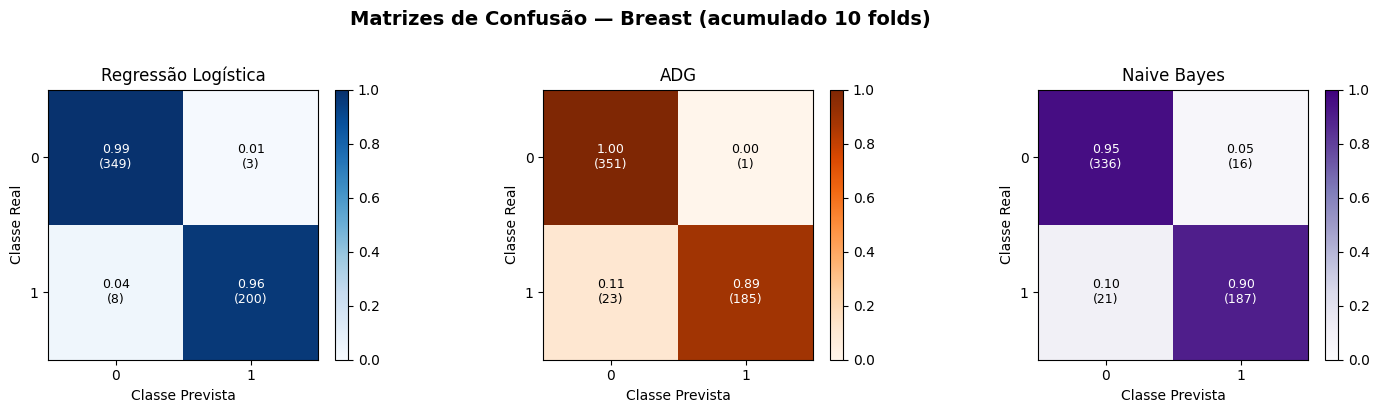

In [402]:
# plot das matrizes de confusão para cada abordagem
plotar_matrizes(
    mcs=[mc_lr, mc_adg, mc_nb],
    titulos=['Regressão Logística', 'ADG', 'Naive Bayes'],
    classes=classes_breast,
    titulo_geral='Matrizes de Confusão — Breast (acumulado 10 folds)',
    cmaps=['Blues', 'Oranges', 'Purples']  
)

## Questão 02 

a) Considerando uma validação cruzada em 10 folds, avalie modelos de *classificação multiclasse* nos dados em questão.

b) Para cada modelo criado, reporte valor médio e desvio padrão da acurácia
global e da acurácia por classe.

In [403]:
vehicle = np.genfromtxt("vehicle.csv", delimiter=",")

In [404]:
y = vehicle[:, [-1]].astype(int)
X_raw = vehicle[:, :-1].astype(float)

folds = kfold_ind(10, X_raw, y)

### Matriz de confusão - dados

In [405]:
classes_vehicle = sorted(np.unique(y.flatten()).tolist())
K_vehicle = len(classes_vehicle)

mc_sm_v  = np.zeros((K_vehicle, K_vehicle), dtype=int)
mc_adg_v = np.zeros((K_vehicle, K_vehicle), dtype=int)
mc_nb_v  = np.zeros((K_vehicle, K_vehicle), dtype=int)

### Regressão Softmax

In [406]:
def one_hot(y, K):
    y = y.flatten().astype(int)
    Y = np.zeros((len(y), K))
    Y[np.arange(len(y)), y] = 1
    return Y

In [407]:
def softmax(Z):
    Z_est = Z - np.max(Z, axis=1, keepdims=True)  # estabilidade numérica
    exp_Z = np.exp(Z_est)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)


In [408]:
def gd_softmax(alfa, epsilon, epocas, X, y, W):
    n = X.shape[0]
    K = W.shape[1]
    Y_onehot = one_hot(y, K)
    custo = []

    for epoca in range(epocas):
        Z = X @ W 
        Y_est = softmax(Z)

        grad = X.T @ (Y_onehot - Y_est) / n
        W = W + alfa * grad

        Y_clip = np.clip(Y_est, epsilon, 1 - epsilon)
        f_custo = -np.mean(np.sum(Y_onehot * np.log(Y_clip), axis=1))
        custo.append(f_custo)

    return W, custo

In [409]:
def prever_softmax(X, W):
    Y_est = softmax(X @ W)
    return np.argmax(Y_est, axis=1).reshape(-1, 1)

In [410]:
accs_g_sm, accs_c_sm = [], []

for fold_idx, fold in enumerate(folds):
    X_tr = fold['X_treino']
    y_tr = fold['y_treino']
    X_te = fold['X_teste']
    y_te = fold['y_teste']

    W = np.zeros((fold['X_treino'].shape[1], K_vehicle))
    W_final, historico_custo = gd_softmax(0.1, 1e-7, 1000, X_tr, y_tr, W)
    y_pred_sm = prever_softmax(X_te, W_final)

    mc_sm_v += matriz_confusao(y_te, y_pred_sm, classes_vehicle)

    acc_g, acc_c = calcular_metricas(y_te, y_pred_sm)  # ← corrigido
    accs_g_sm.append(acc_g)
    accs_c_sm.append(acc_c)

    print(f"Fold {fold_idx+1:2d} | Custo final: {historico_custo[-1]:.4f} "
          f"| Acc global: {acc_g:.4f}")

Fold  1 | Custo final: 0.5371 | Acc global: 0.7024
Fold  2 | Custo final: 0.5385 | Acc global: 0.7738
Fold  3 | Custo final: 0.5407 | Acc global: 0.7976
Fold  4 | Custo final: 0.5332 | Acc global: 0.7262
Fold  5 | Custo final: 0.5424 | Acc global: 0.7619
Fold  6 | Custo final: 0.5416 | Acc global: 0.8452
Fold  7 | Custo final: 0.5237 | Acc global: 0.6667
Fold  8 | Custo final: 0.5437 | Acc global: 0.7381
Fold  9 | Custo final: 0.5303 | Acc global: 0.7738
Fold 10 | Custo final: 0.5405 | Acc global: 0.7500


In [411]:
print("\n Resumo K-fold para Regressão Softmax")
print(f"Acurácia global -> média: {np.mean(accs_g_sm)} | desvio padrão: {np.std(accs_g_sm)}")

# acurácia por classe
classes_unicas = sorted(np.unique(y.flatten()))
for c in classes_unicas:
    vals = [fold_acc[c] for fold_acc in accs_c_sm if c in fold_acc]
    print(f"Acurácia classe {c} -> média: {np.mean(vals)} | desvio padrão: {np.std(vals)}")


 Resumo K-fold para Regressão Softmax
Acurácia global -> média: 0.7535714285714286 | desvio padrão: 0.04733546512397869
Acurácia classe 0 -> média: 0.9145931029754559 | desvio padrão: 0.056883732166758696
Acurácia classe 1 -> média: 0.5603549783549784 | desvio padrão: 0.12338596240320966
Acurácia classe 2 -> média: 0.5767234328150415 | desvio padrão: 0.11648703826289926
Acurácia classe 3 -> média: 0.9681286549707602 | desvio padrão: 0.06326136748106242


### Análise do Discriminante Gaussiano (utilizando funções anteriormente definidas)

In [412]:
accs_g_adg, accs_c_adg = [], []

for fold_idx, fold in enumerate(folds):
    X_tr = fold['X_treino'][:, 1:]  # remove intercepto
    X_te = fold['X_teste'][:, 1:]
    y_tr = fold['y_treino']
    y_te = fold['y_teste']

    params_adg = adg_fit(fold['X_treino'][:, 1:], fold['y_treino'])
    y_pred_adg = adg_predict(params_adg, fold['X_teste'][:, 1:])
    mc_adg_v += matriz_confusao(fold['y_teste'], y_pred_adg, classes_vehicle)

    acc_g, acc_c = calcular_metricas(y_te, y_pred_adg)
    accs_g_adg.append(acc_g)
    accs_c_adg.append(acc_c)

    print(f"Fold {fold_idx+1} | Acc global: {acc_g}")

Fold 1 | Acc global: 0.75
Fold 2 | Acc global: 0.7857142857142857
Fold 3 | Acc global: 0.8214285714285714
Fold 4 | Acc global: 0.7380952380952381
Fold 5 | Acc global: 0.8214285714285714
Fold 6 | Acc global: 0.7976190476190477
Fold 7 | Acc global: 0.7142857142857143
Fold 8 | Acc global: 0.7976190476190477
Fold 9 | Acc global: 0.7380952380952381
Fold 10 | Acc global: 0.7738095238095238


In [413]:
print("\n Resumo K-fold para Análise do Discriminante Gaussiano ")
print(f"Acurácia global -> média: {np.mean(accs_g_adg)} | desvio padrão: {np.std(accs_g_adg)}")
for c in classes_unicas:
    vals = [fold_acc[c] for fold_acc in accs_c_adg if c in fold_acc]
    print(f"Acurácia classe {c} -> média: {np.mean(vals)} | desvio padrão: {np.std(vals)}")


 Resumo K-fold para Análise do Discriminante Gaussiano 
Acurácia global -> média: 0.7738095238095238 | desvio padrão: 0.03531523089093171
Acurácia classe 0 -> média: 0.9537908496732026 | desvio padrão: 0.058547500516564786
Acurácia classe 1 -> média: 0.6063711626064567 | desvio padrão: 0.11318369820989657
Acurácia classe 2 -> média: 0.5775001760112219 | desvio padrão: 0.07726074290093582
Acurácia classe 3 -> média: 0.9607316821465428 | desvio padrão: 0.04928029546525723


### Naive Bayes Gaussiano (utilizando funções anteriormente definidas)

In [414]:
accs_g_nb, accs_c_nb = [], []

for fold_idx, fold in enumerate(folds):
    X_tr = fold['X_treino'][:, 1:]  # remove intercepto
    X_te = fold['X_teste'][:, 1:]
    y_tr = fold['y_treino']
    y_te = fold['y_teste']

    params_nb = nb_fit(fold['X_treino'][:, 1:], fold['y_treino'])
    y_pred_nb = nb_predict(params_nb, fold['X_teste'][:, 1:])
    mc_nb_v += matriz_confusao(fold['y_teste'], y_pred_nb, classes_vehicle)

    acc_g, acc_c = calcular_metricas(y_te, y_pred_nb)
    accs_g_nb.append(acc_g)
    accs_c_nb.append(acc_c)

    print(f"Fold {fold_idx+1} | Acc global: {acc_g}")

Fold 1 | Acc global: 0.4523809523809524
Fold 2 | Acc global: 0.36904761904761907
Fold 3 | Acc global: 0.4166666666666667
Fold 4 | Acc global: 0.5
Fold 5 | Acc global: 0.42857142857142855
Fold 6 | Acc global: 0.5119047619047619
Fold 7 | Acc global: 0.35714285714285715
Fold 8 | Acc global: 0.4523809523809524
Fold 9 | Acc global: 0.5
Fold 10 | Acc global: 0.5357142857142857


In [415]:
print("\nResumo K-fold para Naive Bayes Gaussiano:")
print(f"Acurácia global -> média: {np.mean(accs_g_nb)} | desvio padrão: {np.std(accs_g_nb)}")
for c in classes_unicas:
    vals = [fold_acc[c] for fold_acc in accs_c_nb if c in fold_acc]
    print(f"Acurácia classe {c} -> média: {np.mean(vals)} | desvio padrão: {np.std(vals)}")


Resumo K-fold para Naive Bayes Gaussiano:
Acurácia global -> média: 0.4523809523809524 | desvio padrão: 0.05734092656567758
Acurácia classe 0 -> média: 0.17069025092554505 | desvio padrão: 0.08133473970175426
Acurácia classe 1 -> média: 0.41663011063011063 | desvio padrão: 0.12756012913342388
Acurácia classe 2 -> média: 0.3991099377312447 | desvio padrão: 0.07824909619645573
Acurácia classe 3 -> média: 0.8617489311514079 | desvio padrão: 0.08070570750096144


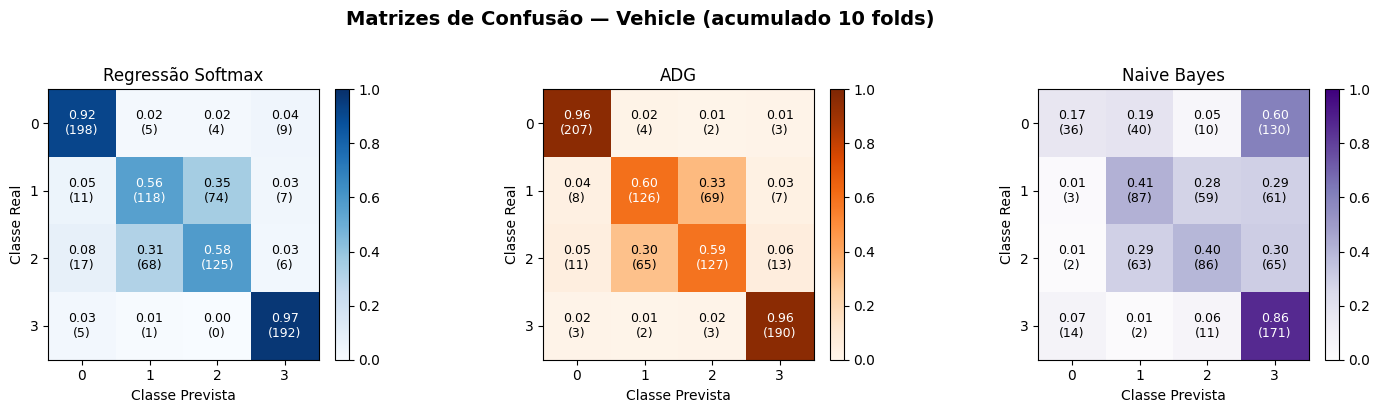

In [416]:
# plot das matrizes de confusão para cada abordagem
plotar_matrizes(
    mcs=[mc_sm_v, mc_adg_v, mc_nb_v],
    titulos=['Regressão Softmax', 'ADG', 'Naive Bayes'],
    classes=classes_vehicle,
    titulo_geral='Matrizes de Confusão — Vehicle (acumulado 10 folds)',
    cmaps=['Blues', 'Oranges', 'Purples']
)